In [1]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\YuMeow\WorkSpace\35-HuaweiCrowdSimulation\HuaweiCrowdSimulationCode


C:\Users\YuMeow\AppData\Local\Temp\ipykernel_60516\3367564046.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


(np.float64(-6.134374666062355),
 np.float64(5.680985529917512),
 np.float64(-10.398706565969793),
 np.float64(5.37239792508714))

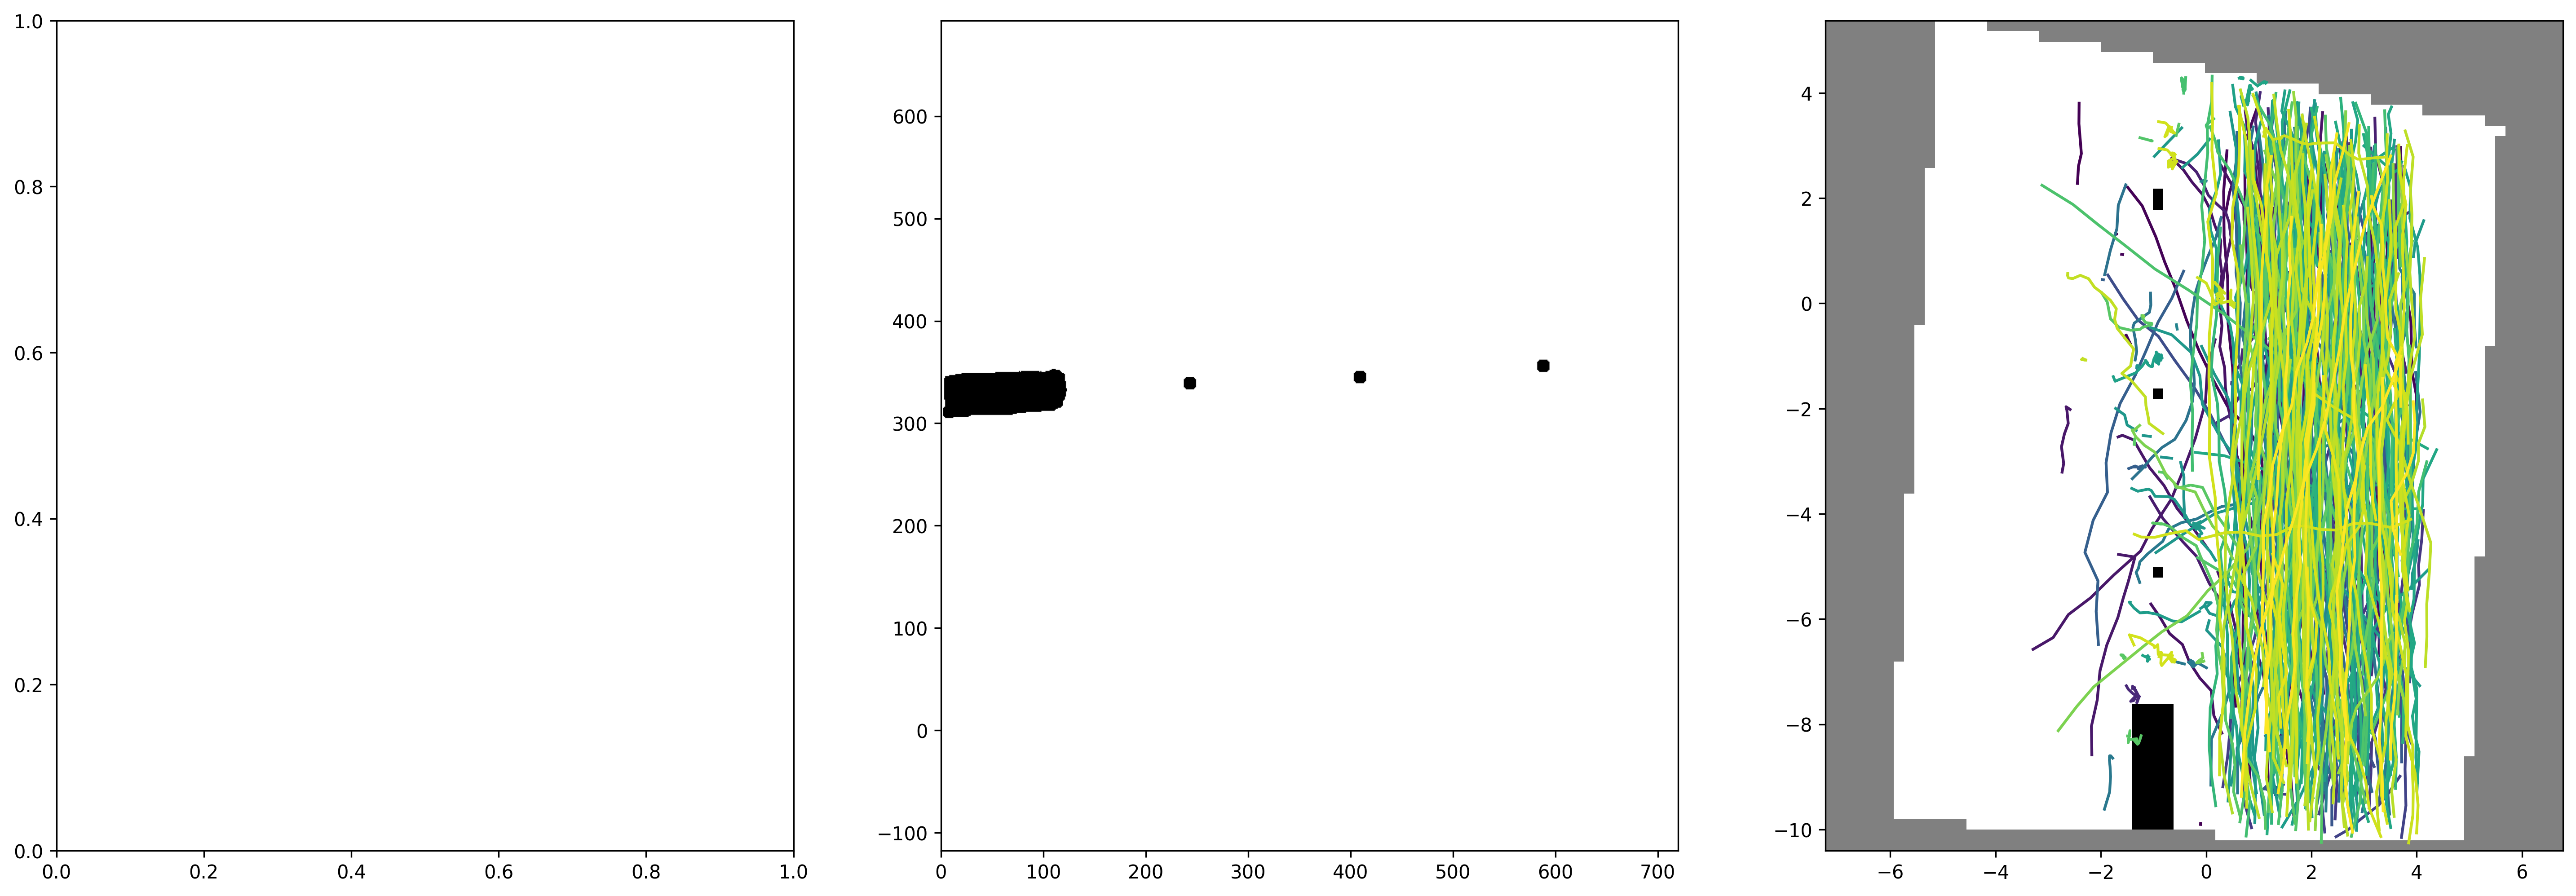

In [ ]:
import os
import sys
import torch
import logging
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from typing import List
from io import StringIO
from pathlib import Path
from argparse import Namespace
from scipy.interpolate import griddata
from src.dataset.base_dataset import BaseDataset
from src.dataset.eth_dataset import ETHDataset
from src.utils.homography import image_to_world
import matplotlib.pyplot as plt

data_path = Path('data/ETH/seq_hotel/obsmat.txt')
name = data_path.parent.name.removeprefix("seq_")

## 读取数据
df_data = pd.read_csv(
    data_path,
    sep=' ',
    names=['f', 'id', 'x', 'z', 'y', 'vx', 'vz', 'vy'],
    usecols=['f', 'id', 'x', 'y'],
    skipinitialspace=True,
)
df_data['type'] = 'pedestrian'

## 数据重采样
df_data = BaseDataset.resample_dataframe(df_data, raw_fps=ETHDataset.raw_fps, target_fps=2.5)

## 创建地图
H = np.loadtxt(data_path.parent / "H.txt")  # (3, 3)
image = np.array(Image.open('data/ETH/seq_hotel/map.png').convert('L')) # (H, W)
map, xmin, xmax, ymin, ymax = image_to_world(image, H, dot_per_meter=5.0)

## 可视化
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=300)
# image0 = np.array(Image.open('data/UCY/data/Arxiepiskopi_flock.jpg'))  # (H, W)
# h, w = image0.shape[:2]
# # axes[0].imshow(image0, extent=(0, w, 0, h))
# for pid, group in df_data.groupby('id'):
#     cmap = plt.cm.get_cmap('viridis')
#     axes[0].plot(group['raw_x'], group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))
# axes[0].axis('equal')
h, w = image.shape[:2]
axes[1].imshow(image, extent=(0, w, 0, h), cmap='gray_r')
# for pid, group in df_data.groupby('id'):
#     cmap = plt.cm.get_cmap('viridis')
#     axes[1].plot(group['raw_x'], group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))
axes[1].axis('equal')
axes[2].imshow(map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    axes[2].plot(group['x'], group['y'], color=cmap(group['f'].max() / df_data['f'].max()))
axes[2].set_facecolor('gray')
axes[2].axis('equal')